In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from premium_calculator import calculate_premium
import numpy as np

In [2]:
#Loading the dataset
df = pd.read_csv("../data/insurance.csv")

In [3]:
df["smoker"]=df["smoker"].fillna("no")
df["smoker_boolean"]=df["smoker"] =="yes"

In [4]:
claim_severity_smoker=df[df["smoker_boolean"]]["charges"].mean()
claim_severity_nonsmoker=df[~df["smoker_boolean"]]["charges"].mean()


In [5]:
#Estimating probability of smokers and non smokers (for non zero claim size)

prob_smoker=len(df[(df["charges"]>claim_severity_smoker) & (df["smoker_boolean"])])/len(df[df["smoker_boolean"]])
prob_nonsmoker=len(df[(df["charges"]>claim_severity_nonsmoker) & (~df["smoker_boolean"])])/len(df[~df["smoker_boolean"]])
print(f"probability of smoker:{prob_smoker} and of non smoker : {prob_nonsmoker}")

probability of smoker:0.5474452554744526 and of non smoker : 0.4342105263157895


In [6]:
df["premium"] = df.apply(lambda row: calculate_premium(row["age"], row["smoker_boolean"]), axis=1)

In [7]:
df = df.copy()

In [42]:
print("Current Means:", df.groupby("smoker")["premium"].mean())



Current Means: smoker
no     15245.622688
yes    29077.461758
Name: premium, dtype: float64


In [43]:
df.head()

,age,sex,bmi,children,smoker,region,charges,smoker_boolean,premium
0,19,female,27.900,0,yes,southwest,16884.92400,True,28531.476357
1,18,male,33.770,1,no,southeast,1725.55230,False,14660.472312
2,28,male,33.000,3,no,southeast,4449.46200,False,14660.472312
3,33,male,22.705,0,no,northwest,21984.47061,False,14810.472312
4,32,male,28.880,0,no,northwest,3866.85520,False,14760.472312


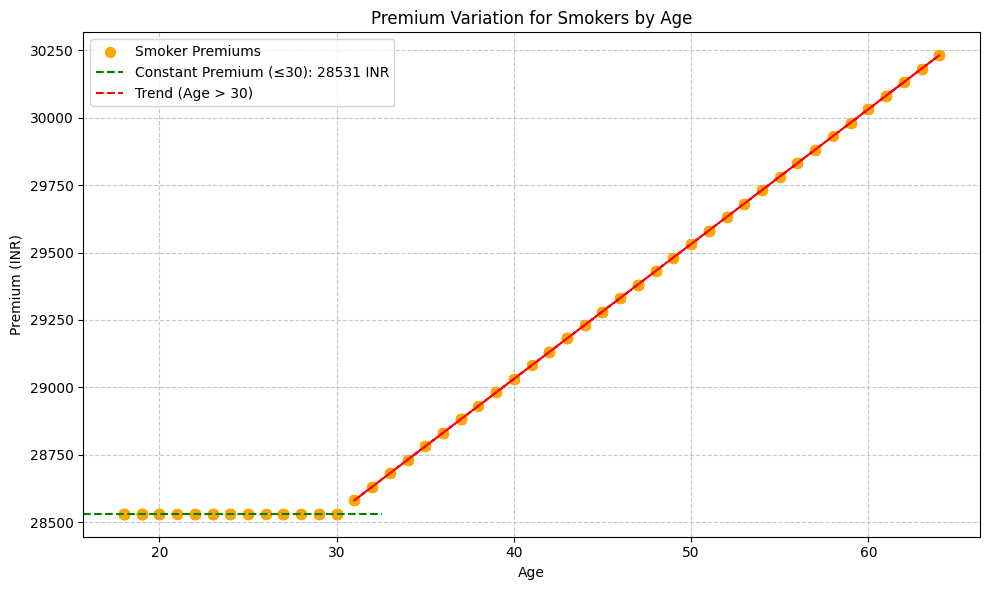

In [ ]:
smoker_data=df.query("smoker_boolean==True")[["age","premium"]]
plt.figure(figsize=(10, 6))

# Plot scatter
plt.scatter(smoker_data["age"], smoker_data["premium"], color="orange", s=50, label="Smoker Premiums")

under_30_data = smoker_data[smoker_data["age"] <= 30]
if not under_30_data.empty:
    expected_premium = under_30_data["premium"].mean()
    plt.axhline(y=expected_premium, xmin=0, xmax=2/6, color="green", linestyle="--", label=f"Constant Premium (≤30): {expected_premium:.0f} INR")

over_30_data = smoker_data[smoker_data["age"] > 30]
if not over_30_data.empty:
    z = np.polyfit(over_30_data["age"], over_30_data["premium"], 1)
    p = np.poly1d(z)
    plt.plot(over_30_data["age"], p(over_30_data["age"]), "r--", label="Trend (Age > 30)")

plt.title("Premium Variation for Smokers by Age", fontsize=12)
plt.xlabel("Age", fontsize=10)
plt.ylabel("Premium (INR)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

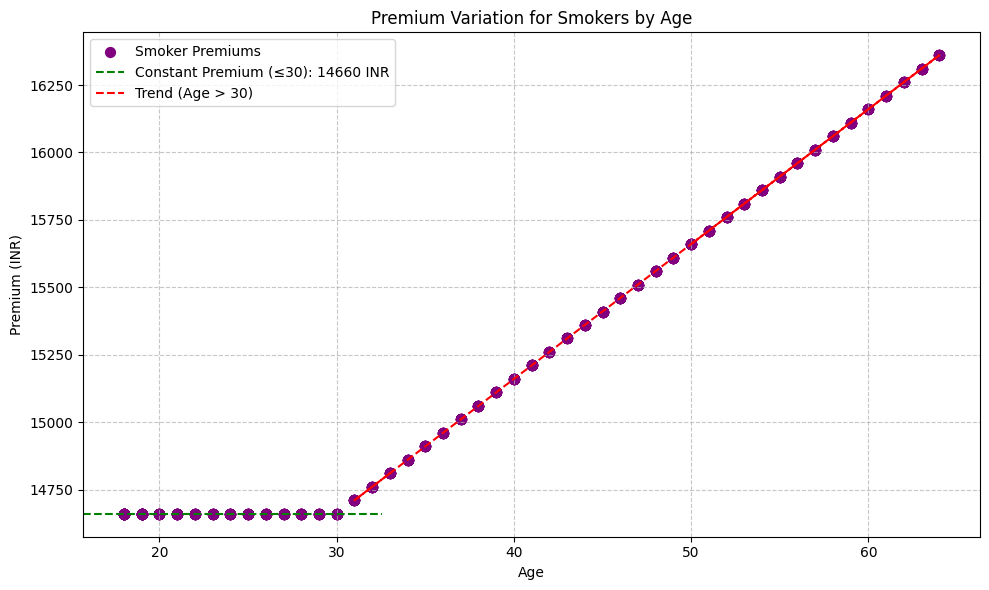

In [78]:
smoker_data=df.query("smoker_boolean==False")[["age","premium"]]
plt.figure(figsize=(10, 6))

# Plot scatter
plt.scatter(smoker_data["age"], smoker_data["premium"], color="purple", s=50, label="Smoker Premiums")

under_30_data = smoker_data[smoker_data["age"] <= 30]
if not under_30_data.empty:
    expected_premium = under_30_data["premium"].mean()
    plt.axhline(y=expected_premium, xmin=0, xmax=2/6, color="green", linestyle="--", label=f"Constant Premium (≤30): {expected_premium:.0f} INR")

over_30_data = smoker_data[smoker_data["age"] > 30]
if not over_30_data.empty:
    z = np.polyfit(over_30_data["age"], over_30_data["premium"], 1)
    p = np.poly1d(z)
    plt.plot(over_30_data["age"], p(over_30_data["age"]), "r--", label="Trend (Age > 30)")

plt.title("Premium Variation for Smokers by Age", fontsize=12)
plt.xlabel("Age", fontsize=10)
plt.ylabel("Premium (INR)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
df.query("smoker_boolean==False")["premium"]

1       14660.472312
2       14660.472312
3       14810.472312
4       14760.472312
5       14710.472312
            ...     
1332    15760.472312
1333    15660.472312
1334    14660.472312
1335    14660.472312
1336    14660.472312
Name: premium, Length: 1064, dtype: float64

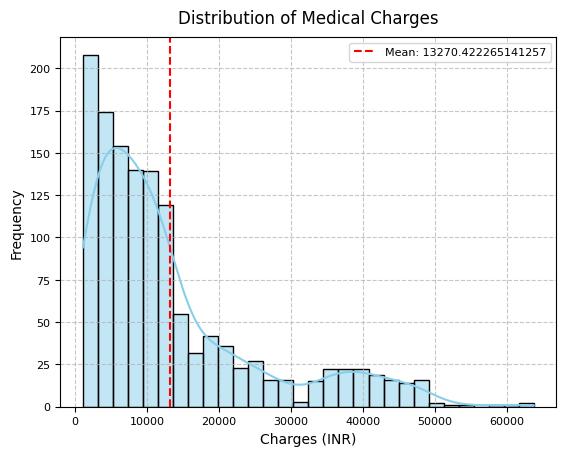

In [94]:
sns.histplot(data=df, x="charges", bins=30, kde=True, color="skyblue")
plt.title("Distribution of Medical Charges", fontsize=12, pad=10)
plt.xlabel("Charges (INR)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.axvline(df["charges"].mean(), color="red", linestyle="--", label=f"Mean: {df['charges'].mean()}")
plt.legend(fontsize=8)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()